# Árboles de Decisión
## Clasificación mediante particiones del espacio

Un **Árbol de Decisión** es un modelo de clasificación que divide el espacio de características en regiones utilizando reglas simples.

En lugar de buscar una frontera lineal, el modelo crea **reglas binarias** que separan los datos.

## Idea central

El modelo aprende reglas del tipo:

si x1 < 1.7
    clase = 0
si x1 ≥ 1.7
    clase = 1

Estas reglas generan una estructura jerárquica llamada **árbol**.

Cada nodo del árbol realiza una pregunta sobre una variable.

## Cómo se construye el árbol

Durante el entrenamiento el algoritmo busca divisiones que separen mejor las clases utilizando criterios como:

- **Gini impurity**
- **Entropy (information gain)**

Estas métricas miden qué tan "puras" quedan las regiones después de dividir los datos.

## Interpretación geométrica

Los árboles de decisión dividen el espacio con **cortes paralelos a los ejes**.

Esto genera regiones **rectangulares (2D)** o **rectangulares tridimensionales (3D)**.

A diferencia de modelos lineales, el árbol puede producir **fronteras de decisión no lineales**.

## Ventajas

- Muy **interpretables**
- Funcionan con datos no lineales
- No requieren escalamiento de variables

## Limitaciones

- Pueden **sobreajustar** los datos
- Las fronteras pueden ser irregulares si el árbol crece demasiado

## Qué se observará en este notebook

1. Se cargará un dataset sintético
2. Se entrenará un **Árbol de Decisión**
3. Se evaluará el modelo en test
4. Se visualizará el comportamiento del clasificador




In [1]:
# Cell — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Cell 2 — Importando módulo propio

from utils.classification_functions import *

In [3]:
# Cell 3 — Leyendo datos

DATA_FILE = "binary_classification_separable_3d.csv"  # cambiar aquí

data_path = Path("../data/mocked_data") / DATA_FILE
df = pd.read_csv(data_path)

X = df.drop(columns=["y"])
y = df["y"]

print(f"Dataset loaded: {DATA_FILE}")
print(f"Shape: {df.shape}")

df.head()

Dataset loaded: binary_classification_separable_3d.csv
Shape: (10000, 4)


,x1,x2,x3,y
0,-0.089699,1.313391,-3.115777,0
1,-0.718095,2.546880,-2.033826,0
2,-1.511018,3.531431,-1.418384,0
3,-0.722646,3.548436,-1.535807,0
4,-1.530624,3.172766,-2.843698,0


In [4]:
# Cell — Train/Test split

TEST_SIZE = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (8000, 3)
Test set: (2000, 3)


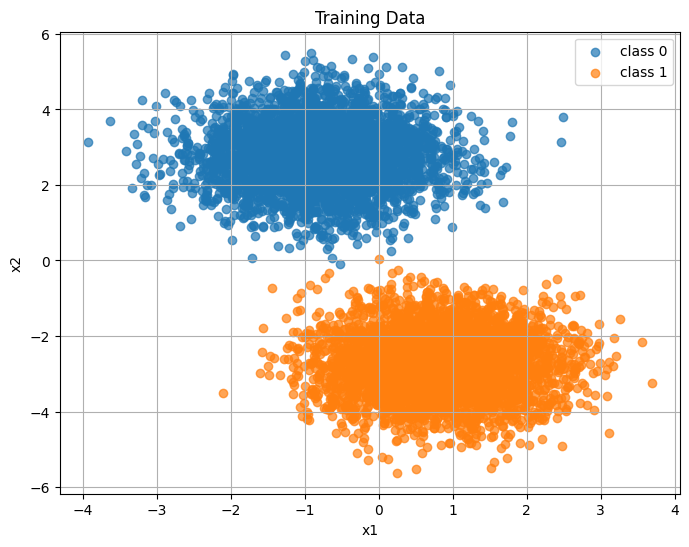

In [5]:
plot_points(
    X_train.to_numpy(),
    y_train.to_numpy(),
    dims=2,
    title="Training Data"
)

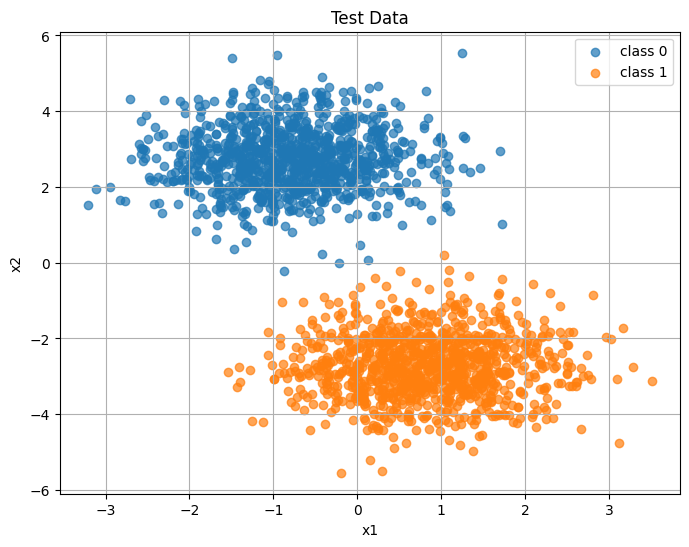

In [6]:
plot_points(
    X_test.to_numpy(),
    y_test.to_numpy(),
    dims=2,
    title="Test Data"
)

## Entrenando Árbol de Decisión

In [7]:
# Cell — Hyperparameters

TREE_PARAMS = {

    "criterion": "gini",       # "gini" o "entropy"
    "max_depth": None,         # profundidad máxima del árbol
    "min_samples_split": 2,    # mínimo de muestras para dividir
    "min_samples_leaf": 1,     # mínimo de muestras en hoja
    "random_state": RANDOM_SEED

}

In [8]:
# Cell — Training

model = DecisionTreeClassifier(**TREE_PARAMS)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [9]:
# Cell — Inspect model

clf = model

print("Tree depth:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())
print("Feature importances:", clf.feature_importances_)

Tree depth: 3
Number of leaves: 4
Feature importances: [0.00000000e+00 9.99750125e-01 2.49875031e-04]


Test Accuracy: 0.9990

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



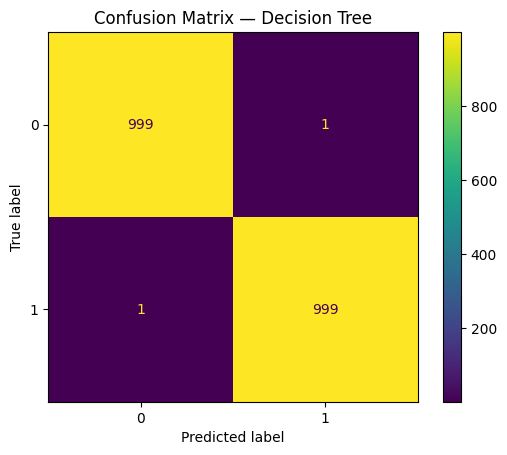

In [10]:
# Cell — Evaluation

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix — Decision Tree")

plt.show()

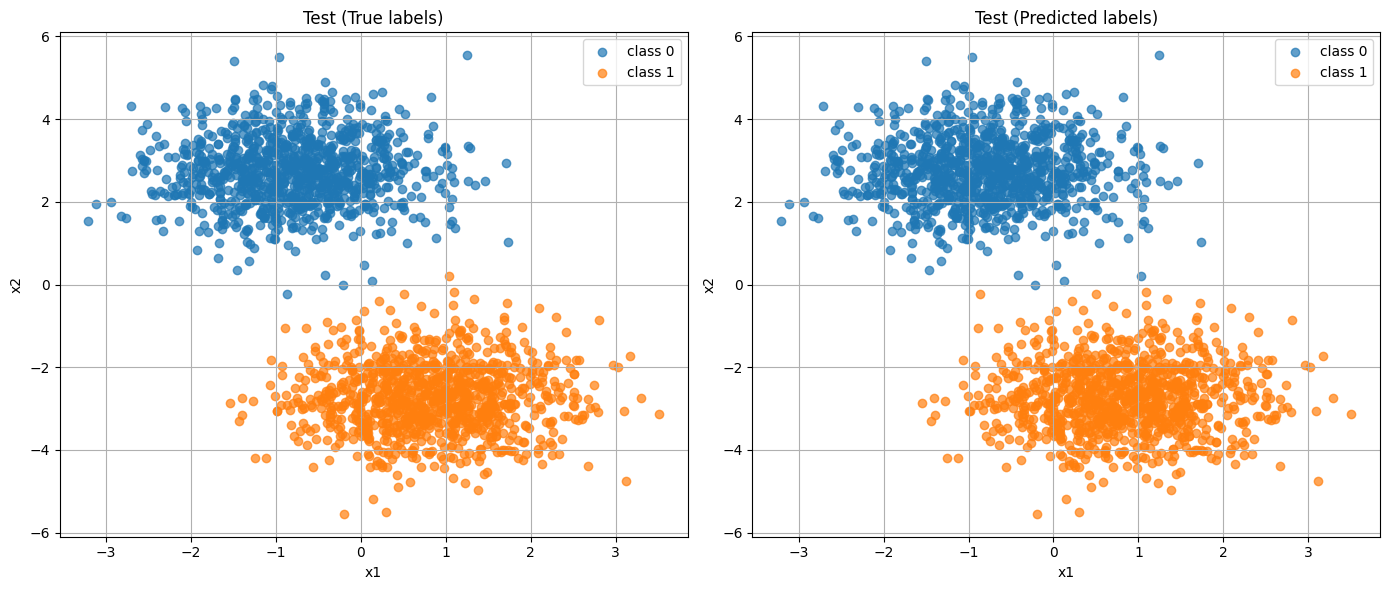

In [11]:
plot_true_vs_pred(
    X_test,
    y_test,
    y_pred,
    dims=2,
    elev=25,
    azim=45
)